<a href="https://colab.research.google.com/github/dyjdlopez/fund_opts_python/blob/main/metaheuristics/metaopts_02_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2.2: Nature-Inspired Optimization
$_\text{Metaheuristics and Optimization | D.J.D. Lopez | 2026}$


Nature-based metaheuristics are a class of optimization algorithms inspired by biological and social systems, where many simple agents interact locally yet collectively solve complex search problems. Instead of relying on gradients or convexity, these algorithms treat the objective as a black box and use population-based stochastic search guided by metaphors such as bird flocking, ant foraging, wolf hunting, slime mould foraging, and Darwinian evolution to iteratively improve candidate solutions. Swarm intelligence methods (PSO, ACO, FOA, SMA, GWO) emphasize decentralized control, self-organization, and the balance of exploration vs. exploitation through local communication (e.g., pheromone trails or neighborhood influence), while evolutionary algorithms (GA, EP) simulate natural selection via fitness-based selection, crossover, and mutation to evolve better solutions over generations.

Because they only require objective function evaluations, nature-based metaheuristics can tackle nonlinear, discontinuous, and mixed-variable optimization problems that are difficult for classical solvers, at the cost of more computation and no guarantee of a global optimum. In this coding-oriented notebook, we will implement key swarm and evolutionary algorithms (e.g., PSO, ACO, GWO, GA) from scratch, visualize how their populations move through the search space, and explore how to adapt them to operations-research models by encoding decision variables appropriately, handling constraints with penalties or repairs, and optionally hybridizing them with exact solvers for refinement.

## 1. Swarm Intelligence

Swarm intelligence refers to the **collective behavior** of large groups of simple agents—such as birds, fish, ants, or artificial particles—that coordinate through local interactions without any central controller. Each agent follows simple rules based on nearby information, yet the swarm as a whole self-organizes to explore the search space and concentrate around promising regions, yielding robust and scalable problem-solving behavior. In metaheuristic optimization, algorithms like Particle Swarm Optimization, Ant Colony Optimization, Grey Wolf Optimizer, Fruit Fly Optimization, and Slime Mold Algorithm implement this paradigm by encoding candidate solutions as agents whose positions are iteratively updated through a balance of exploration and exploitation.

### Example: Juice Bottling MINLP

Consider a small juice bottling startup that must decide its daily production and machine activation.

We define four decision variables:
- $x_1$: liters of orange juice to produce (continuous, $x_1 \ge 0$)
- $x_2$: liters of mango juice to produce (continuous, $x_2 \ge 0$)
- $z_1$: number of orange-juice bottling lines to activate (integer, $z_1 \in \mathbb{Z}_{+}$)
- $z_2$: number of mango-juice bottling lines to activate (integer, $z_2 \in \mathbb{Z}_{+}$)

Each orange line can process up to 4 liters per day, and each mango line up to 3 liters per day.
The company wants to stay close to target volumes of 3 L orange and 1 L mango, keep line activation costs low, and account for coordination overhead between the two products.

We model this as the following mixed-integer nonlinear program (MINLP):

$$
\min_{x_1, x_2, z_1, z_2}\;
f(x_1,x_2,z_1,z_2)
= (x_1 - 3)^2 + (x_2 - 1)^2 + 0.5 z_1 + 0.8 z_2 + 0.2 x_1 x_2
$$

subject to capacity constraints
$$
x_1 \le 4 z_1, \qquad x_2 \le 3 z_2,
$$

a weighted demand constraint
$$
x_1 + 2x_2 \ge 5,
$$

and domain constraints
$$
x_1, x_2 \ge 0, \qquad z_1, z_2 \in \mathbb{Z}_{+}.
$$


In [1]:
import cvxpy as cp

# Decision variables
x1 = cp.Variable()
x2 = cp.Variable()
z1 = cp.Variable(integer=True)
z2 = cp.Variable(integer=True)

deviation_orange = (x1 - 3)**2          # deviation from 3 L orange target
deviation_mango  = (x2 - 1)**2          # deviation from 1 L mango target
cost_orange_lines = 0.5 * z1            # cost per orange line
cost_mango_lines  = 0.8 * z2            # cost per mango line
coordination_penalty = 0.2 * x1 * x2    # interaction penalty between products

objective = cp.Minimize(
    deviation_orange
    + deviation_mango
    + cost_orange_lines
    + cost_mango_lines
    + coordination_penalty
)

constraints = [
    x1 <= 4 * z1,
    x2 <= 3 * z2,
    x1 + 2 * x2 >= 5,
    x1 >= 0,
    x2 >= 0,
    z1 >= 0,
    z2 >= 0,
]

prob = cp.Problem(objective, constraints)
prob.solve()

print("Status:", prob.status)
print("Optimal value:", prob.value)
print("x1 =", x1.value, "x2 =", x2.value)
print("z1 =", z1.value, "z2 =", z2.value)


DCPError: Problem does not follow DCP rules. Specifically:
The objective is not DCP. Its following subexpressions are not:
0.2 @ var1 @ var2


When we try to solve the juice bottling MINLP in CVXPY, we obtain a `DCPError` because the model violates the **Disciplined Convex Programming (DCP)** rules that CVXPY uses to guarantee convexity.

In our objective,
$$
f(x_1,x_2,z_1,z_2)
= (x_1 - 3)^2 + (x_2 - 1)^2 + 0.5 z_1 + 0.8 z_2 + 0.2 x_1 x_2,
$$
the term $0.2 x_1 x_2$ is **bilinear** (a product of two decision variables), which makes the problem nonconvex and outside the class of DCP-compliant models that CVXPY accepts by default. CVXPY checks the expression tree and detects that this subexpression is neither convex nor concave under its rules, so it raises an error instead of passing an invalid “convex” problem to a solver.

This limitation is typical for realistic mixed-integer nonlinear programs (MINLPs), where we often see products, ratios, or other nonconvex terms. Instead of trying to force such problems into a convex form, we can treat the MINLP as a black-box objective
$$
\min\ f(x_1,x_2,z_1,z_2) \quad \text{subject to capacity, demand, and integrality constraints,}
$$
and let **nature-based metaheuristics** search over feasible decisions.Swarm intelligence methods like Particle Swarm Optimization, Ant Colony Optimization, or Grey Wolf Optimizer do not require convexity or derivatives; they only need to evaluate $f$ and check whether a candidate $(x_1,x_2,z_1,z_2)$ is feasible, which makes them powerful tools for tackling nonconvex MINLPs that lie beyond CVXPY’s DCP-safe region.

In [2]:
import numpy as np

def juice_bottling_obj(solution: np.ndarray) -> float:
    x1, x2, z1, z2 = solution

    z1 = np.round(z1)
    z2 = np.round(z2)

    # Base objective components
    deviation_orange = (x1 - 3.0)**2
    deviation_mango  = (x2 - 1.0)**2
    cost_orange_lines = 0.5 * z1
    cost_mango_lines  = 0.8 * z2
    coordination_penalty = 0.2 * x1 * x2

    base_obj = (
        deviation_orange
        + deviation_mango
        + cost_orange_lines
        + cost_mango_lines
        + coordination_penalty
    )

    # Constraint violations
    penalty = 0.0
    big_M = 1e4  # large penalty weight

    # Capacity
    cap1_violation = max(0.0, x1 - 4.0 * z1)
    cap2_violation = max(0.0, x2 - 3.0 * z2)

    # Demand
    demand_violation = max(0.0, 5.0 - (x1 + 2.0 * x2))

    nonneg_violations = [
        max(0.0, -x1),
        max(0.0, -x2),
        max(0.0, -z1),
        max(0.0, -z2),
    ]

    penalty += big_M * (
        cap1_violation**2
        + cap2_violation**2
        + demand_violation**2
        + sum(v**2 for v in nonneg_violations)
    )

    return base_obj + penalty


In [ ]:
# %pip install mealpy

In [67]:
from mealpy.swarm_based import PSO
from mealpy import FloatVar

# Bounds for [x1, x2, z1, z2]
bounds = FloatVar(
    lb=[0.0, 0.0, 0.0, 0.0],
    ub=[6.0, 6.0, 5.0, 5.0],
    name="juice_vars"
)

problem = {
    "obj_func": juice_bottling_obj,
    "bounds": bounds,
    "minmax": "min",
    "log_to": None
}

model = PSO.OriginalPSO(
    epoch=100,
    pop_size=10
)

model.solve(problem)
log_path = "PSO_juice_log.txt"

gbest_list = model.history.list_global_best_fit
lbest_list = model.history.list_current_best_fit

with open(log_path, "w") as f:
    f.write("iter,local_best,global_best\n")
    for it, (lb, gb) in enumerate(zip(lbest_list, gbest_list)):
        f.write(f"{it},{lb},{gb}\n")

print("Iteration log (local and global best) saved to:", log_path)

# Best solution
best_agent = model.g_best
best_pos = best_agent.solution
best_fit = best_agent.target.fitness

x1_best, x2_best, z1_best, z2_best = best_pos
z1_best = int(round(z1_best))
z2_best = int(round(z2_best))

print("Best fitness:", best_fit)
print(f"x1 = {x1_best:.3f}, x2 = {x2_best:.3f}, z1 = {z1_best}, z2 = {z2_best}")

Iteration log (local and global best) saved to: PSO_juice_log.txt
Best fitness: 1.899997471134023
x1 = 3.001, x2 = 1.000, z1 = 1, z2 = 1


#### *Constraint Violation Validation*

Violation checking is necessary because PSO minimizes a penalized objective and can return a point that has low cost but still violates one or more constraints if the penalties or stopping criteria are not strict enough. By explicitly computing violations after the run, we can distinguish genuinely feasible solutions from those that only look good due to penalty tuning or floating-point rounding (for example, deciding whether $2.4\times10^{-5}$ is acceptable under a chosen tolerance). This post-processing step turns the metaheuristic,s best particle into a trustworthy MINLP solution and provides feedback for adjusting penalty weights or repair rules in future runs.

In [31]:
def check_constraints(x1, x2, z1, z2):
    # round integer-like variables
    z1 = int(round(z1))
    z2 = int(round(z2))

    print(f"Checking solution: x1={x1:.3f}, x2={x2:.3f}, z1={z1}, z2={z2}")

    # Capacity constraints
    cap1 = x1 - 4.0 * z1     # should be <= 0
    cap2 = x2 - 3.0 * z2     # should be <= 0

    # Demand constraint
    demand = 5.0 - (x1 + 2.0 * x2)   # should be <= 0

    # Nonnegativity
    nn_x1 = -x1      # should be <= 0
    nn_x2 = -x2
    nn_z1 = -z1
    nn_z2 = -z2

    print(f"x1 <= 4 z1 : violation = {max(0.0, cap1):.6f}")
    print(f"x2 <= 3 z2 : violation = {max(0.0, cap2):.6f}")
    print(f"x1 + 2 x2 >= 5 : violation = {max(0.0, demand):.6f}")
    print(f"x1 >= 0 : violation = {max(0.0, nn_x1):.6f}")
    print(f"x2 >= 0 : violation = {max(0.0, nn_x2):.6f}")
    print(f"z1 >= 0 : violation = {max(0.0, nn_z1):.6f}")
    print(f"z2 >= 0 : violation = {max(0.0, nn_z2):.6f}")

check_constraints(x1_best, x2_best, z1_best, z2_best)

Checking solution: x1=3.047, x2=0.976, z1=3, z2=1
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000034
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


#### *Visualizing the optimization convergence*

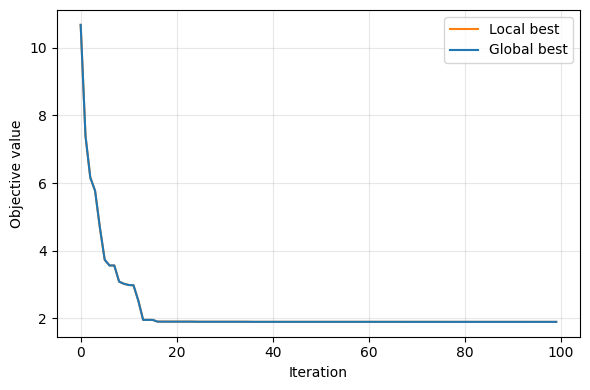

In [68]:
import matplotlib.pyplot as plt

def plot_results(logs):
  data = np.loadtxt(logs, delimiter=",", skiprows=1)
  iters = data[:, 0]
  lbest = data[:, 1]
  gbest = data[:, 2]

  plt.figure(figsize=(6, 4))
  plt.plot(iters, lbest, label="Local best", color="tab:orange")
  plt.plot(iters, gbest, label="Global best", color="tab:blue")
  plt.xlabel("Iteration")
  plt.ylabel("Objective value")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

plot_results('PSO_juice_log.txt')

### 1.1. Ant Colony Optimization

Ant Colony Optimization (ACO) is a swarm-intelligence metaheuristic inspired by how real ants find shortest paths between their nest and food sources by laying and following pheromone trails on the ground. In ACO, artificial ants construct solutions step by step on a graph, choosing the next move with a probability that depends on both pheromone intensity (collective memory of good past solutions) and a heuristic term like inverse distance or cost, so that edges that belong to better tours receive more pheromone and are more likely to be reused. Pheromone evaporation gradually weakens all trails over time, preventing premature convergence and maintaining a balance between exploring new paths and exploiting the best routes discovered so far.

In Mealpy, ACO is implemented as the continuous Ant Colony Optimization for Real domains (ACOR), and you use it exactly like PSO by passing your objective and bounds in a problem dictionary. You only need to import `ACOR.OriginalACOR`, define the same juice bottling objective and variable bounds, then call model.solve(problem) to let a population of “ants” sample new candidate solutions from Gaussian kernels around good solutions instead of moving particles with velocities.

In ACOR (continuous ant colony optimization), we control:

- The number of iterations (epochs) $T$ and the population size $N$ (number of ants).
- The **sample count** $q$, which is the number of new candidate solutions sampled per iteration.
- The **intent factor** $\xi \in (0,1)$, which sets the selection pressure by giving higher probability to better ants when sampling.
- The parameter $\zeta > 0$, which controls the spread of the Gaussian kernels around each ant’s position (larger $\zeta$ means wider sampling, smaller $\zeta$ means tighter sampling).

In [37]:
from mealpy.swarm_based import ACOR

def optimize(model, algo_name):

  problem = {
    "obj_func": juice_bottling_obj,
    "bounds": bounds,
    "minmax": "min",
    "log_to": None
  }

  model.solve(problem)

  best_agent = model.g_best
  best_pos = best_agent.solution
  best_fit = best_agent.target.fitness

  log_path = f"{algo_name}_juice_log.txt"

  gbest_list = model.history.list_global_best_fit
  lbest_list = model.history.list_current_best_fit

  with open(log_path, "w") as f:
      f.write("iter,local_best,global_best\n")
      for it, (lb, gb) in enumerate(zip(lbest_list, gbest_list)):
          f.write(f"{it},{lb},{gb}\n")

  print("Iteration log (local and global best) saved to:", log_path)

  x1_best, x2_best, z1_best, z2_best = best_pos
  z1_best = int(round(z1_best))
  z2_best = int(round(z2_best))

  print(f"{algo_name} best fitness:", best_fit)
  print(f"{algo_name}: x1 = {x1_best:.3f}, x2 = {x2_best:.3f}, z1 = {z1_best}, z2 = {z2_best}")

  return x1_best, x2_best, z1_best, z2_best

model_aco = ACOR.OriginalACOR(
    epoch=100,
    pop_size=30,
    sample_count=25,    # number of new samples per iteration
    intent_factor=0.5,  # selection pressure
    zeta=1.0            # deviation-distance ratio
)

x1_best, x2_best, z1_best, z2_best = optimize(model_aco, 'ACO')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: ACO_juice_log.txt
ACO best fitness: 1.8982946311627376
ACO: x1 = 3.030, x2 = 0.985, z1 = 1, z2 = 1
Checking solution: x1=3.030, x2=0.985, z1=1, z2=1
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000175
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


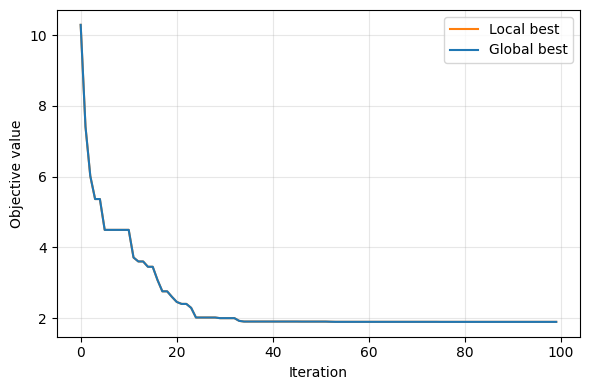

In [38]:
plot_results('ACO_juice_log.txt')

### 1.2. Fruit Fly Optimization

Fruit Fly Optimization Algorithm (FOA) is a swarm-intelligence method inspired by how fruit flies search for food using their strong sense of smell to explore broadly around a central location and then use vision to move toward the best-smelling spot once a promising area is found. In the basic FOA loop, each fruit fly samples a random position around the current swarm center (smell-based exploration), the algorithm evaluates the “smell concentration” via the objective function for all flies, and then the swarm center is updated toward the best individual (vision-based exploitation), repeating this process until a stopping criterion is met.

In Mealpy, use the `mealpy.swarm_based.FOA`. The key hyperparameters are:

- The number of iterations (epochs) $T$ and the population size $N$, which together determine how long and how broadly the swarm explores the search space.
- The step-size parameter $\alpha$, which controls the search radius of the fruit flies (larger $\alpha$ encourages stronger exploration).
- The decay parameter $\beta$, which controls how quickly the search radius shrinks over time (smaller $\beta$ keeps exploration active longer, larger $\beta$ shifts the algorithm more quickly toward exploitation).




In [61]:
from mealpy.swarm_based import FOA

model_foa = FOA.OriginalFOA(
    epoch=100,
    pop_size=50,
    alpha=2.5,
    beta=0.9,
)
x1_best, x2_best, z1_best, z2_best = optimize(model_foa, 'FOA')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: FOA_juice_log.txt
FOA best fitness: 4.1696591889102
FOA: x1 = 3.395, x2 = 1.880, z1 = 4, z2 = 5
Checking solution: x1=3.395, x2=1.880, z1=4, z2=5
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000000
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


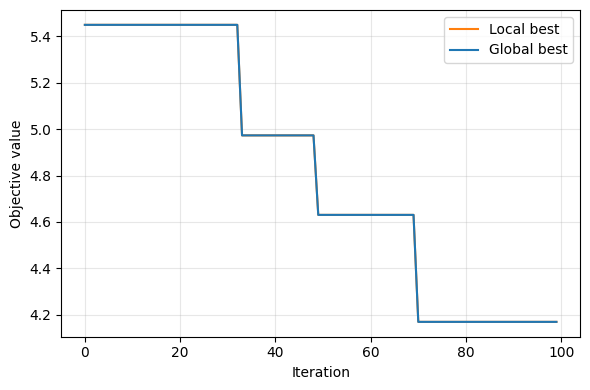

In [62]:
plot_results('FOA_juice_log.txt')

### 1.3. Slime Mold Optimization

The Slime Mold Algorithm (SMA) is a swarm-based metaheuristic inspired by the oscillatory foraging behavior of slime moulds (such as *Physarum polycephalum*), which expand and contract a vein-like network while searching for rich food sources. SMA models this behavior with agents that alternate between “approach food” and “wrap food” phases using adaptive weights and feedback from their fitness values, allowing the population to dynamically balance global exploration of the search space and local exploitation around the best regions.


In Mealpy, use the `mealpy.swarm_based.SMA`. The key hyperparameters are:

- The number of iterations (epochs) $T$ and the population size $N$, which together determine how long and how broadly the slime-mould swarm explores the search space.
- One or more weight-control parameters (often denoted by factors in the SMA update rule) that shape the oscillatory coefficients and regulate how strongly agents are pulled toward the current best versus pushed to explore.
- Version-specific coefficients that scale the attraction–repulsion terms and random perturbations, which can be tuned to emphasize either global exploration (larger stochastic terms) or local exploitation (stronger pull toward the best solutions).

In [63]:
from mealpy.bio_based import SMA

model_sma = SMA.OriginalSMA(
        epoch=100,
    pop_size=50,
    pr=0.03,    # SMA-specific parameter controlling randomization
)
x1_best, x2_best, z1_best, z2_best = optimize(model_sma, 'SMA')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: SMA_juice_log.txt
SMA best fitness: 1.8979123203732822
SMA: x1 = 3.052, x2 = 0.974, z1 = 1, z2 = 1
Checking solution: x1=3.052, x2=0.974, z1=1, z2=1
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000032
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


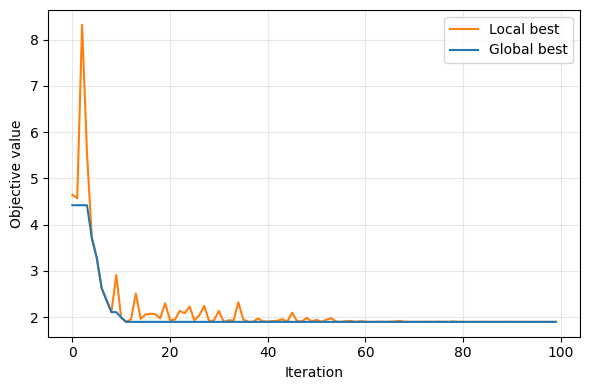

In [64]:
plot_results('SMA_juice_log.txt')

### 1.4. Gray Wolf Optimization
Gray Wolf Optimizer (GWO) is a swarm-intelligence metaheuristic that mimics the social hierarchy and cooperative hunting of grey wolves, where the best three wolves (alpha, beta, delta) guide the rest of the pack (omega) to track, encircle, and attack the prey, corresponding to converging toward good solutions in the search space.At each iteration, omega wolves update their positions based on the positions of alpha, beta, and delta, while a control parameter $a$ decreases over time so that the search gradually shifts from wide exploration to fine-grained exploitation around the current best solutions.

In Mealpy, use the `mealpy.swarm_based.GWO`. The key hyperparameters are:

- The number of iterations (epochs) $T$ and the population size $N$, which together determine how long the wolf pack hunts and how many candidate solutions (wolves) are evaluated in parallel at each step.
- The (implicit) control parameter $a$ in the GWO update rule, which typically starts near $2$ and linearly decreases toward $0$, so that when $|A| > 1$ the wolves explore far from the leaders, and when $|A| < 1$ they exploit by moving closer to the alpha-beta-delta positions.
- Any implementation-specific options (e.g., initialization ranges or boundary handling strategies) that influence how wolves are placed in the search space and how they are reflected or clipped when they approach variable bounds, affecting the balance between exploration and respecting constraints.

In [65]:
from mealpy.swarm_based import GWO

model_gwo = GWO.OriginalGWO(
    epoch=100,
    pop_size=30,
)
x1_best, x2_best, z1_best, z2_best = optimize(model_gwo, 'GWO')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: GWO_juice_log.txt
GWO best fitness: 1.8981086647682974
GWO: x1 = 3.047, x2 = 0.977, z1 = 1, z2 = 1
Checking solution: x1=3.047, x2=0.977, z1=1, z2=1
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000000
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


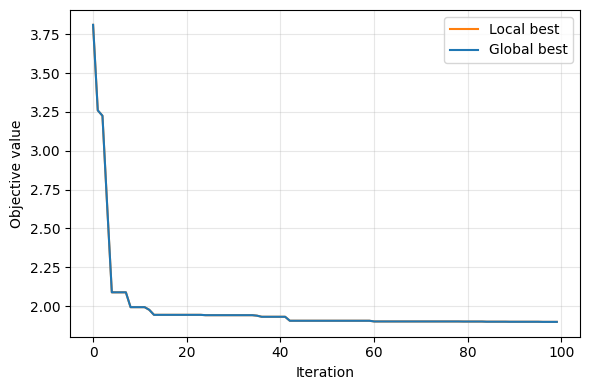

In [66]:
plot_results('GWO_juice_log.txt')

### *Comparing Convergences*

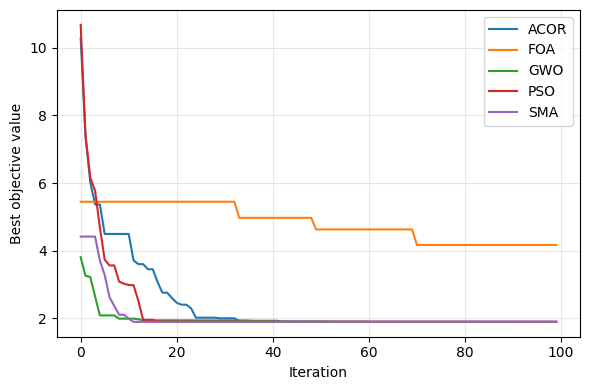

In [70]:
import os
import glob
import pandas as pd


records = []

# Adjust patterns if your logs use different extensions
for path in glob.glob("*.txt") + glob.glob("*.log"):
    name = os.path.basename(path)
    lname = name.lower()

    # Infer algorithm from filename
    if "pso" in lname:
        algo = "PSO"
    elif "aco" in lname or "acor" in lname:
        algo = "ACOR"
    elif "foa" in lname or "fruit" in lname:
        algo = "FOA"
    elif "sma" in lname:
        algo = "SMA"
    elif "gwo" in lname:
        algo = "GWO"
    else:
        continue  # skip unknown logs

    try:
        df = pd.read_csv(path)
    except Exception:
        try:
            df = pd.read_csv(path, header=None)
        except Exception:
            continue

    # Assume last numeric column is global best (gbest)
    num_cols = df.select_dtypes(include="number").columns
    if len(num_cols) == 0:
        continue
    gbest_col = num_cols[-1]

    for it, val in enumerate(df[gbest_col].values):
        records.append({"iter": it, "gbest": val, "algo": algo})

all_df = pd.DataFrame(records)

# Plot gbest for each algorithm
plt.figure(figsize=(6, 4))
for algo, g in all_df.groupby("algo"):
    plt.plot(g["iter"], g["gbest"], label=algo)
plt.xlabel("Iteration")
plt.ylabel("Best objective value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

What do you observe with the convergences? Which model performs best?

## 2. Evolutionary Algorithms

Evolutionary algorithms are population-based metaheuristics inspired by biological evolution, using selection, crossover, and mutation to iteratively improve candidate solutions.

- Population size $N$: Number of candidate solutions (individuals) evaluated each generation; larger $N$ improves exploration but increases computation.
- Fitness function $f(\mathbf{x})$: Maps a solution $\mathbf{x}$ to a scalar quality measure that the EA tries to minimize or maximize.
- Generations $T$: Number of evolutionary iterations; more generations allow more refinement but cost more evaluations.

### Main operators

- Selection operator $S$: Preferentially picks fitter individuals (e.g., roulette, tournament) so that high-fitness solutions are more likely to reproduce.
- Crossover operator $C$: Combines two parents $\mathbf{x}^{(1)}, \mathbf{x}^{(2)}$ into offspring, e.g. one-point crossover  
  $$
  \mathbf{y}_i =
  \begin{cases}
  x^{(1)}_i, & i \le k \\
  x^{(2)}_i, & i > k
  \end{cases}
  $$
  which exploits good building blocks from both parents.
- Mutation operator $M$: Randomly perturbs an individual to introduce new variation, e.g. Gaussian mutation  
  $$
  \mathbf{y} = \mathbf{x} + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2 I),
  $$
  where $\sigma$ controls the exploration step size.

### Typical EA loop

- Initialize $N$ individuals $\{\mathbf{x}_j^{(0)}\}_{j=1}^N$ (often uniformly within bounds).  
- For each generation $t = 0, 1, \dots, T-1$:
  - Evaluate fitness $f(\mathbf{x}_j^{(t)})$ for all individuals.
  - Apply selection $S$ to choose parents based on fitness.
  - Apply crossover $C$ and mutation $M$ to generate offspring $\{\mathbf{x}_j^{(t+1)}\}$.
- Return the best $\mathbf{x}^\star$ found over all generations.


### 2.1. Genetic Algorithm

A Genetic Algorithm is an evolutionary optimization method that evolves a population of candidate solutions using selection, crossover, and mutation to search for near-optimal solutions.

- Chromosome $\mathbf{x} = (x_1, x_2, \dots, x_n)$: Encoded candidate solution (bit string, real vector, etc.).
- Fitness function $f(\mathbf{x})$: Measures the quality of $\mathbf{x}$; GA aims to minimize or maximize $f$.
- Population size $N$: Number of chromosomes evaluated each generation.

### Main operators

- Selection: Choose parents with probability biased by fitness, e.g. roulette wheel  
  $$
  p_i = \frac{f(\mathbf{x}_i)}{\sum_{j=1}^N f(\mathbf{x}_j)},
  $$
  so fitter individuals are more likely to reproduce.
- Crossover: Recombine two parents $\mathbf{x}^{(1)}, \mathbf{x}^{(2)}$ to form offspring. For single-point crossover at position $k$:  
  $$
  y_i =
  \begin{cases}
  x^{(1)}_i, & i \le k \\
  x^{(2)}_i, & i > k
  \end{cases}
  $$
  which mixes building blocks from both parents.

- Mutation: Randomly perturb genes to introduce variation. For bit-flip mutation with rate $p_m$, each bit $x_i$ is flipped with probability $p_m$; for real-valued GA, a common model is  
  $$
  \mathbf{y} = \mathbf{x} + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2 I).
  $$

### GA loop (high level)

- Initialize $N$ chromosomes $\{\mathbf{x}_j^{(0)}\}_{j=1}^N$ at random within bounds.
- For each generation $t = 0, 1, \dots, T-1$: evaluate $f(\mathbf{x}_j^{(t)})$; select parents; apply crossover and mutation to produce offspring $\{\mathbf{x}_j^{(t+1)}\}$; optionally apply elitism.
- Return the best chromosome $\mathbf{x}^\star$ found over all generations.

In Mealpy, use the `mealpy.evolutionary_based.GA`. The key hyperparameters are:

- The number of generations (epochs) $T$ and the population size $N$ (`epoch`, `pop_size`), which together determine how long the GA evolves and how many candidate solutions are evaluated in each generation.
- The crossover and mutation probabilities $p_c$ and $p_m$ (`pc`, `pm`), which control how often parents are recombined and how strongly offspring are perturbed, balancing exploitation of good solutions versus exploration of new regions.
- The selection, crossover, and mutation operators (`selection`, `crossover`, `mutation`, plus `k_way` for tournament), which specify how parents are chosen and how their chromosomes are mixed and modified, shaping the search behavior of the GA.


In [73]:
from mealpy import GA

model_ga = GA.BaseGA(
    epoch=100,      # T: number of generations
    pop_size=100,    # N: population size
    pc=0.85,        # pc: crossover probability
    pm=0.30,        # pm: mutation probability
    selection="tournament",
    k_way=0.4,      # tournament size (fraction or count)
    crossover="multi_points",
    mutation="swap",
)

x1_best, x2_best, z1_best, z2_best = optimize(model_ga, 'GA')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: GA_juice_log.txt
GA best fitness: 2.568051177675305
GA: x1 = 1.410, x2 = 1.410, z1 = 1, z2 = 2
Checking solution: x1=1.410, x2=1.410, z1=1, z2=2
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.770940
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


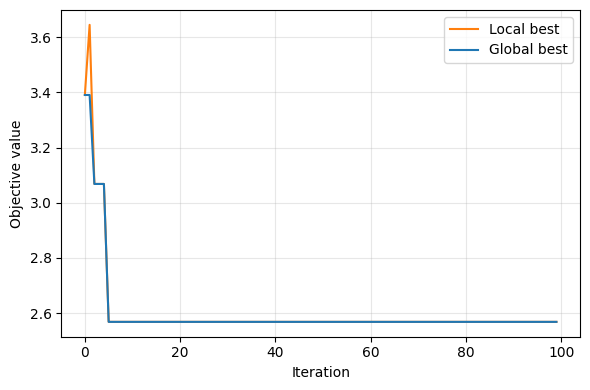

In [74]:
plot_results('GA_juice_log.txt')

### 2.2. Evolutionary Programming


Evolutionary Programming is an evolutionary algorithm that models the evolution of real-valued individuals using **only mutation** and survivor selection, without crossover.

- Population of individuals $\{\mathbf{x}_j^{(t)}\}_{j=1}^N$: each $\mathbf{x}_j$ is typically a real-valued vector of decision variables.
- Fitness function $f(\mathbf{x})$: evaluates the quality of each individual; EP aims to minimize or maximize $f$.

At generation $t$, each parent $\mathbf{x}_j^{(t)}$ produces (usually) one mutated offspring:
  $$
  \mathbf{y}_j^{(t)} = \mathbf{x}_j^{(t)} + \boldsymbol{\epsilon}_j^{(t)},
  $$
  where $\boldsymbol{\epsilon}_j^{(t)}$ is drawn from a mutation distribution (e.g. Gaussian, Cauchy, or Lévy).
Parents and offspring are pooled, and a survivor selection (often tournament-based) chooses $N$ individuals to form the next generation.

**How EP differs from GA**

- GA uses both crossover and mutation on chromosomes, while EP uses mutation as the **sole** variation operator and does not use crossover.
- GA often encodes solutions as bit strings or structured chromosomes; EP typically works directly with real-valued vectors and emphasizes self-adaptation of mutation step sizes.
- GA selection usually picks parents before variation; EP often applies tournament selection on the combined pool of parents and offspring **after** mutation to decide survivors.


In Mealpy, use the `mealpy.evolutionary_based.EP` (for example, `EP.LevyEP`). The key hyperparameters are:

- The number of generations (epochs) $T$ and the population size $N$, which together determine how long the EP process runs and how many candidate solutions are evaluated in parallel each generation.
- The mutation/bout parameter (e.g. `bout_size`), which controls how strongly individuals are mutated and how intense the tournament-style survivor selection is, shaping the balance between exploration and exploitation.
- The choice of mutation distribution and strategy adaptation (e.g. Gaussian, Cauchy, or Lévy-like mutation with self-adapting step sizes), which governs how far mutated offspring can jump in the search space and how the mutation step size evolves over time.

In [75]:
from mealpy import EP

model_ep = EP.LevyEP(
    epoch=100,       # T: number of generations
    pop_size=50,     # N: population size
    bout_size=0.05,  # controls tournament/mutation intensity
)

x1_best, x2_best, z1_best, z2_best = optimize(model_ep, 'EP')
check_constraints(x1_best, x2_best, z1_best, z2_best)

Iteration log (local and global best) saved to: EP_juice_log.txt
EP best fitness: 1.899378839231459
EP: x1 = 3.064, x2 = 0.970, z1 = 1, z2 = 1
Checking solution: x1=3.064, x2=0.970, z1=1, z2=1
x1 <= 4 z1 : violation = 0.000000
x2 <= 3 z2 : violation = 0.000000
x1 + 2 x2 >= 5 : violation = 0.000000
x1 >= 0 : violation = 0.000000
x2 >= 0 : violation = 0.000000
z1 >= 0 : violation = 0.000000
z2 >= 0 : violation = 0.000000


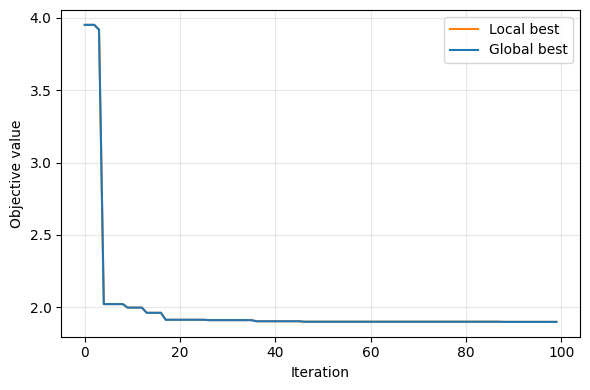

In [76]:
plot_results('EP_juice_log.txt')